In [738]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore5')
%matplotlib inline

ValueError: invalid action: 'ignore5'

## Loading the dataset

In [ ]:
df_title=pd.read_csv('titles.csv')
df_title.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"['fantasy', 'family']",['US'],NaN,tt0032138,8.1,389774.0,41.442,7.6
1,tm83648,Citizen Kane,MOVIE,"Newspaper magnate, Charles Foster Kane is take...",1941,PG,119,['drama'],['US'],NaN,tt0033467,8.3,433804.0,14.383,8.0
2,tm77588,Casablanca,MOVIE,"In Casablanca, Morocco in December 1941, a cyn...",1942,PG,102,"['drama', 'romance', 'war']",['US'],NaN,tt0034583,8.5,558849.0,20.087,8.2
3,tm82363,The Big Sleep,MOVIE,Private Investigator Philip Marlowe is hired b...,1946,NaN,116,"['thriller', 'crime']",['US'],NaN,tt0038355,7.9,84494.0,12.911,7.7
4,tm84701,The Maltese Falcon,MOVIE,A private detective takes on a case that invol...,1941,NaN,100,"['thriller', 'romance', 'crime']",['US'],NaN,tt0033870,8.0,156603.0,12.788,7.8


In [ ]:
df_title.shape

(3294, 15)

In [ ]:
df_title.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3294 entries, 0 to 3293
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    3294 non-null   object 
 1   title                 3294 non-null   object 
 2   type                  3294 non-null   object 
 3   description           3282 non-null   object 
 4   release_year          3294 non-null   int64  
 5   age_certification     2086 non-null   object 
 6   runtime               3294 non-null   int64  
 7   genres                3294 non-null   object 
 8   production_countries  3294 non-null   object 
 9   seasons               756 non-null    float64
 10  imdb_id               2968 non-null   object 
 11  imdb_score            2922 non-null   float64
 12  imdb_votes            2911 non-null   float64
 13  tmdb_popularity       3261 non-null   float64
 14  tmdb_score            3026 non-null   float64
dtypes: float64(5), int64(

In [ ]:
df_title.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,3294.000000,3294.000000,756.000000,2922.000000,2.911000e+03,3261.000000,3026.000000
mean,2001.194293,80.914997,2.998677,6.883949,6.461835e+04,21.105891,6.850099
std,23.542337,38.475347,3.651181,1.059668,1.754617e+05,89.137800,1.081377
min,1901.000000,1.000000,1.000000,1.500000,5.000000e+00,0.050393,1.000000
25%,1995.000000,51.250000,1.000000,6.300000,9.245000e+02,3.450000,6.200000
50%,2010.000000,89.000000,2.000000,7.000000,8.071000e+03,8.561000,6.900000
75%,2018.000000,106.000000,4.000000,7.600000,4.764500e+04,17.711000,7.500000
max,2022.000000,255.000000,52.000000,9.400000,2.555504e+06,4447.894000,10.000000


## Initial Exploration

In [ ]:
numerical_features=[feature for feature in df_title.columns if df_title[feature].dtype !='O']
categorical_features=[feature for feature in df_title.columns if df_title[feature].dtype == 'O']
print(f'categorical features:',categorical_features)
print(f'numerical features:',numerical_features)

categorical features: ['id', 'title', 'type', 'description', 'age_certification', 'genres', 'production_countries', 'imdb_id']
numerical features: ['release_year', 'runtime', 'seasons', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']


In [ ]:
for col in categorical_features:
    print(col)
    print(df_title[col].unique())
    print('-------------')
   
    

id
['tm155702' 'tm83648' 'tm77588' ... 'tm1121489' 'tm1121486' 'tm989132']
-------------
title
['The Wizard of Oz' 'Citizen Kane' 'Casablanca' ...
 'Entre Nos: What She Said' 'Entre Nos: The Winners 2'
 'The Infamous Future']
-------------
type
['MOVIE' 'SHOW']
-------------
description
['Young Dorothy finds herself in a magical world where she makes friends with a lion, a scarecrow and a tin man as they make their way along the yellow brick road to talk with the Wizard and ask for the things they miss most in their lives. The Wicked Witch of the West is the only thing that could stop them.'
 'Newspaper magnate, Charles Foster Kane is taken from his mother as a boy and made the ward of a rich industrialist. As a result, every well-meaning, tyrannical or self-destructive move he makes for the rest of his life appears in some way to be a reaction to that deeply wounding event.'
 'In Casablanca, Morocco in December 1941, a cynical American expatriate meets a former lover, with unforeseen 

In [ ]:
df_title['genres'].unique()

array(["['fantasy', 'family']", "['drama']",
       "['drama', 'romance', 'war']", ...,
       "['fantasy', 'family', 'animation']",
       "['family', 'fantasy', 'animation', 'comedy']",
       "['romance', 'music']"], dtype=object)

## Data cleaning

In [ ]:
df_title.isnull().sum()

id                         0
title                      0
type                       0
description               12
release_year               0
age_certification       1208
runtime                    0
genres                     0
production_countries       0
seasons                 2538
imdb_id                  326
imdb_score               372
imdb_votes               383
tmdb_popularity           33
tmdb_score               268
dtype: int64

In [ ]:
df_title.shape

(3294, 15)

In [ ]:
df_title['seasons']=df_title['seasons'].fillna(0)

In [ ]:
df_title.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"['fantasy', 'family']",['US'],0.0,tt0032138,8.1,389774.0,41.442,7.6
1,tm83648,Citizen Kane,MOVIE,"Newspaper magnate, Charles Foster Kane is take...",1941,PG,119,['drama'],['US'],0.0,tt0033467,8.3,433804.0,14.383,8.0
2,tm77588,Casablanca,MOVIE,"In Casablanca, Morocco in December 1941, a cyn...",1942,PG,102,"['drama', 'romance', 'war']",['US'],0.0,tt0034583,8.5,558849.0,20.087,8.2
3,tm82363,The Big Sleep,MOVIE,Private Investigator Philip Marlowe is hired b...,1946,NaN,116,"['thriller', 'crime']",['US'],0.0,tt0038355,7.9,84494.0,12.911,7.7
4,tm84701,The Maltese Falcon,MOVIE,A private detective takes on a case that invol...,1941,NaN,100,"['thriller', 'romance', 'crime']",['US'],0.0,tt0033870,8.0,156603.0,12.788,7.8


In [ ]:
df_title['age_certification']=df_title['age_certification'].fillna('Unknown')

In [ ]:
df_title.dropna(subset=['imdb_id'], inplace=True)

In [ ]:
df_title.isnull().sum()

id                        0
title                     0
type                      0
description               5
release_year              0
age_certification         0
runtime                   0
genres                    0
production_countries      0
seasons                   0
imdb_id                   0
imdb_score               46
imdb_votes               57
tmdb_popularity          31
tmdb_score              187
dtype: int64

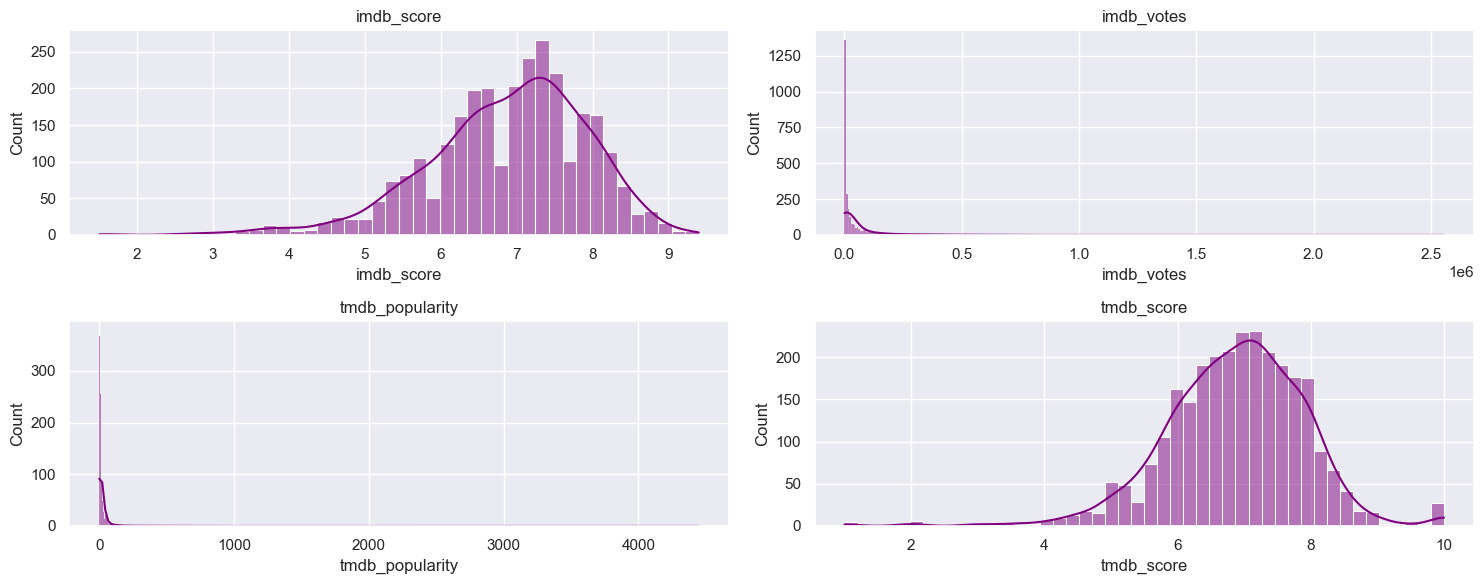

In [ ]:
#Normally distributed-use mean
#skewed or has outliers-median
#imbd_score-left skewed
#imdb_vostes-rightskewed
#tmdb_popularity-right skewed
#tmdb_score-left skewed
#Use median imputation to handle missing values for all the features above.
plt.figure(figsize=(15,6))
features=['imdb_score','imdb_votes','tmdb_popularity','tmdb_score']
for i in range(0,len(features)):
    plt.subplot(2,2,i+1)
    sns.histplot(df_title[features[i]],kde=True,color='purple')
    plt.title(features[i])
plt.tight_layout()
plt.show()

In [ ]:
df_title['imdb_score']=df_title['imdb_score'].fillna(df_title['imdb_score'].median())
df_title['imdb_votes']=df_title['imdb_votes'].fillna(df_title['imdb_votes'].median())
df_title['tmdb_score']=df_title['tmdb_score'].fillna(df_title['tmdb_score'].median())
df_title['tmdb_popularity']=df_title['tmdb_popularity'].fillna(df_title['tmdb_popularity'].median())




In [ ]:
df_title['description']=df_title['description'].fillna('None')

In [ ]:
df_title.isnull().sum()

id                      0
title                   0
type                    0
description             0
release_year            0
age_certification       0
runtime                 0
genres                  0
production_countries    0
seasons                 0
imdb_id                 0
imdb_score              0
imdb_votes              0
tmdb_popularity         0
tmdb_score              0
dtype: int64

Checking and handling duplicates


In [ ]:
df_title[df_title.duplicated()]

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score


In [ ]:
df_title.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2968 entries, 0 to 3293
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    2968 non-null   object 
 1   title                 2968 non-null   object 
 2   type                  2968 non-null   object 
 3   description           2968 non-null   object 
 4   release_year          2968 non-null   int64  
 5   age_certification     2968 non-null   object 
 6   runtime               2968 non-null   int64  
 7   genres                2968 non-null   object 
 8   production_countries  2968 non-null   object 
 9   seasons               2968 non-null   float64
 10  imdb_id               2968 non-null   object 
 11  imdb_score            2968 non-null   float64
 12  imdb_votes            2968 non-null   float64
 13  tmdb_popularity       2968 non-null   float64
 14  tmdb_score            2968 non-null   float64
dtypes: float64(5), int64(2), o

In [ ]:
df_title['genres']=df_title['genres'].str.replace(r"[\[\]']","",regex=True)
df_title['production_countries']=df_title['production_countries'].str.replace(r"[\[\]']","",regex=True)

In [ ]:
df_title.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"fantasy, family",US,0.0,tt0032138,8.1,389774.0,41.442,7.6
1,tm83648,Citizen Kane,MOVIE,"Newspaper magnate, Charles Foster Kane is take...",1941,PG,119,drama,US,0.0,tt0033467,8.3,433804.0,14.383,8.0
2,tm77588,Casablanca,MOVIE,"In Casablanca, Morocco in December 1941, a cyn...",1942,PG,102,"drama, romance, war",US,0.0,tt0034583,8.5,558849.0,20.087,8.2
3,tm82363,The Big Sleep,MOVIE,Private Investigator Philip Marlowe is hired b...,1946,Unknown,116,"thriller, crime",US,0.0,tt0038355,7.9,84494.0,12.911,7.7
4,tm84701,The Maltese Falcon,MOVIE,A private detective takes on a case that invol...,1941,Unknown,100,"thriller, romance, crime",US,0.0,tt0033870,8.0,156603.0,12.788,7.8


In [ ]:
df_title['production_countries'].unique()

array(['US', 'JP', 'GB', 'DE', 'IT', 'FR', 'SE', 'FR, DE', 'SU', 'GB, CA',
       'FR, US', 'IT, US', 'IT, XG, FR, DE', 'CH', 'DK', '', 'US, GB',
       'GB, US', 'CA', 'XC, FR', 'IT, FR', 'FR, IT', 'IT, DZ', 'AU',
       'DE, IR, FR', 'FR, BE', 'XC', 'IN', 'ES, CH', 'DZ, FR',
       'BR, FR, IT', 'DE, SE, FR', 'PL', 'SE, FR', 'FR, SN', 'JP, US',
       'BE, FR, DE', 'IN, US, FR', 'ES, CH, FR', 'FR, SU', 'SN', 'US, HK',
       'MX', 'ES, US', 'AT', 'NO', 'HK, US', 'US, MX', 'US, ES, GB, IT',
       'CA, US', 'FR, GB, DE', 'HK', 'US, CA', 'US, CA, IL', 'US, BE',
       'US, NL', 'FR, IT, GB, CN', 'GB, US, IE', 'ES', 'SE, DE, FR',
       'US, AU', 'FR, DE, PL', 'DE, US', 'DE, FR, IT', 'MX, US', 'FR, CH',
       'US, DE', 'GB, NZ, AU', 'AR', 'CA, IL', 'DE, FR', 'XX', 'KR',
       'CN, HK', 'JP, US, DE', 'FR, US, CA', 'US, GB, JP', 'US, JP',
       'JP, GB, IE', 'BE', 'JP, AR, HK', 'FR, GB', 'NZ, GB, US, DK, FR',
       'FR, PL, CH', 'GB, US, DE, JP, NZ', 'JP, GB, US, DE',
       'NL, NO, 

In [ ]:
#Remove extra spaces.
df_title['production_countries']=df_title['production_countries'].str.replace(' ','')

In [ ]:
df_title['production_countries'].unique()

array(['US', 'JP', 'GB', 'DE', 'IT', 'FR', 'SE', 'FR,DE', 'SU', 'GB,CA',
       'FR,US', 'IT,US', 'IT,XG,FR,DE', 'CH', 'DK', '', 'US,GB', 'GB,US',
       'CA', 'XC,FR', 'IT,FR', 'FR,IT', 'IT,DZ', 'AU', 'DE,IR,FR',
       'FR,BE', 'XC', 'IN', 'ES,CH', 'DZ,FR', 'BR,FR,IT', 'DE,SE,FR',
       'PL', 'SE,FR', 'FR,SN', 'JP,US', 'BE,FR,DE', 'IN,US,FR',
       'ES,CH,FR', 'FR,SU', 'SN', 'US,HK', 'MX', 'ES,US', 'AT', 'NO',
       'HK,US', 'US,MX', 'US,ES,GB,IT', 'CA,US', 'FR,GB,DE', 'HK',
       'US,CA', 'US,CA,IL', 'US,BE', 'US,NL', 'FR,IT,GB,CN', 'GB,US,IE',
       'ES', 'SE,DE,FR', 'US,AU', 'FR,DE,PL', 'DE,US', 'DE,FR,IT',
       'MX,US', 'FR,CH', 'US,DE', 'GB,NZ,AU', 'AR', 'CA,IL', 'DE,FR',
       'XX', 'KR', 'CN,HK', 'JP,US,DE', 'FR,US,CA', 'US,GB,JP', 'US,JP',
       'JP,GB,IE', 'BE', 'JP,AR,HK', 'FR,GB', 'NZ,GB,US,DK,FR',
       'FR,PL,CH', 'GB,US,DE,JP,NZ', 'JP,GB,US,DE',
       'NL,NO,ES,SE,GB,DK,FR,IS', 'GB,US,FR,IT,JP', 'FR,JP,GB,US,DE',
       'PL,FR', 'FR,IR', 'AU,US', 'AT,CH', 'SE

In [ ]:
#Handling outliers
numerical_features

['release_year',
 'runtime',
 'seasons',
 'imdb_score',
 'imdb_votes',
 'tmdb_popularity',
 'tmdb_score']

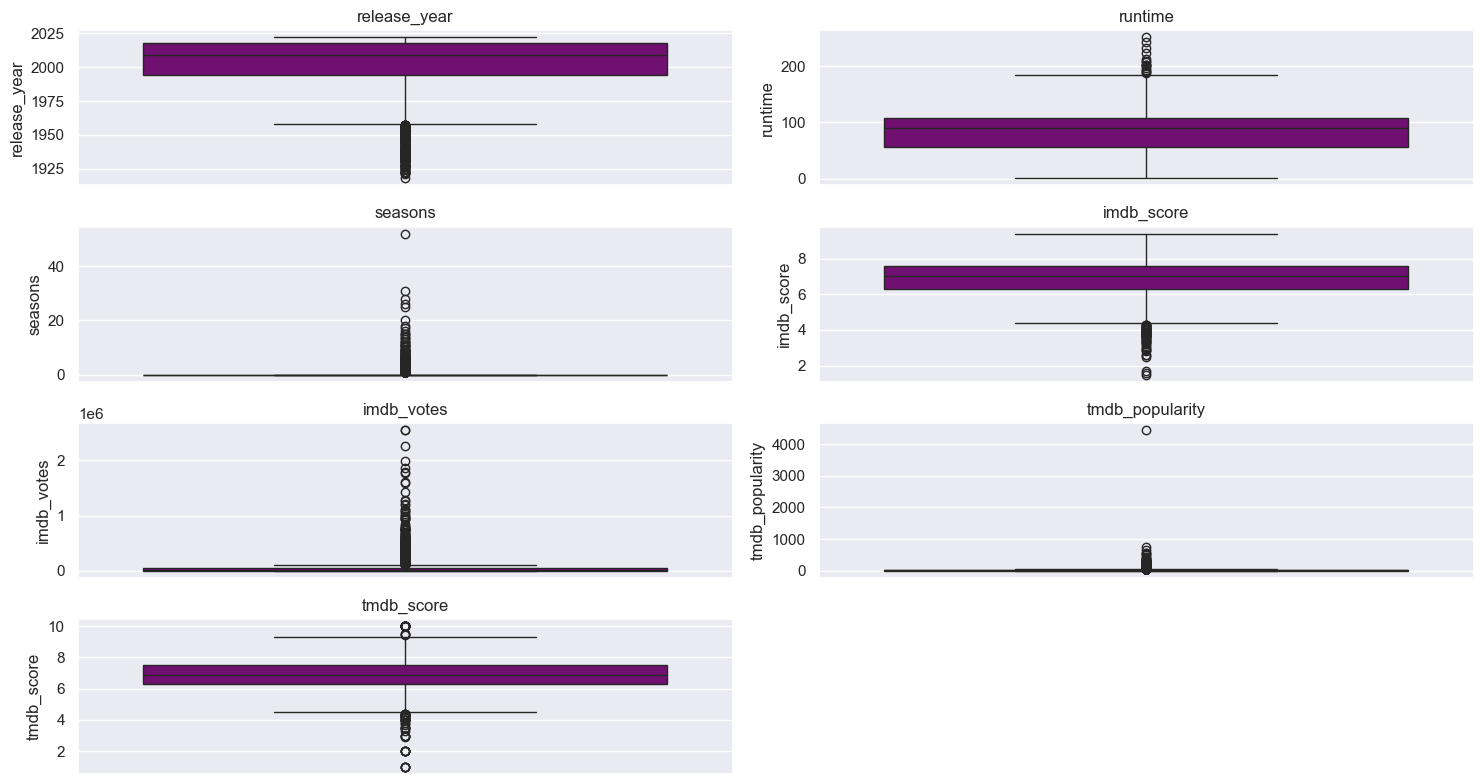

In [ ]:

plt.figure(figsize=(15,8))
for i in range(0,len(numerical_features)):
    plt.subplot(4, 2, i+1)
    sns.boxplot(y=df_title[numerical_features[i]],color='purple')
    plt.title(numerical_features[i])
plt.tight_layout()
plt.show()

Outlier analysis was performed using boxplots. Extreme values were observed in tmdb_popularity and imdb_votes feature; 
however,these values represent genuine differences in movie popularity and were retained

In [ ]:
df_credits=pd.read_csv('credits.csv')
df_credits.head()

,person_id,id,name,character,role
0,60017,tm155702,Judy Garland,Dorothy Gale,ACTOR
1,53496,tm155702,Ray Bolger,Hunk / Scarecrow,ACTOR
2,79549,tm155702,Jack Haley,Hickory / Tin Man,ACTOR
3,79548,tm155702,Bert Lahr,Zeke / Cowardly Lion,ACTOR
4,60995,tm155702,Margaret Hamilton,Elmira Gulch / Wicked Witch of the West,ACTOR


In [ ]:
df_credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66393 entries, 0 to 66392
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   person_id  66393 non-null  int64 
 1   id         66393 non-null  object
 2   name       66393 non-null  object
 3   character  61888 non-null  object
 4   role       66393 non-null  object
dtypes: int64(1), object(4)
memory usage: 2.5+ MB


In [ ]:
df_credits.describe()

,person_id
count,6.639300e+04
mean,3.479124e+05
std,5.539732e+05
min,7.000000e+00
25%,1.754400e+04
50%,7.037900e+04
75%,4.835320e+05
max,2.369354e+06


In [ ]:
df_credits.shape

(66393, 5)

## Data cleaning

In [ ]:
df_credits.isnull().sum()

person_id       0
id              0
name            0
character    4505
role            0
dtype: int64

In [ ]:
df_credits.dropna(subset='character',inplace=True)

In [ ]:
df_credits.isnull().sum()

person_id    0
id           0
name         0
character    0
role         0
dtype: int64

In [ ]:
df_credits['character']

0                                   Dorothy Gale
1                               Hunk / Scarecrow
2                              Hickory / Tin Man
3                           Zeke / Cowardly Lion
4        Elmira Gulch / Wicked Witch of the West
                          ...                   
66386                          Oficial Contreras
66387                          Oficial Jaramillo
66388                                      Marta
66389                                    Claudia
66390                                       Nora
Name: character, Length: 61888, dtype: object

In [ ]:
df=pd.merge(df_title,df_credits,on='id',how='inner')

In [ ]:
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"fantasy, family",US,0.0,tt0032138,8.1,389774.0,41.442,7.6,60017,Judy Garland,Dorothy Gale,ACTOR
1,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"fantasy, family",US,0.0,tt0032138,8.1,389774.0,41.442,7.6,53496,Ray Bolger,Hunk / Scarecrow,ACTOR
2,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"fantasy, family",US,0.0,tt0032138,8.1,389774.0,41.442,7.6,79549,Jack Haley,Hickory / Tin Man,ACTOR
3,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"fantasy, family",US,0.0,tt0032138,8.1,389774.0,41.442,7.6,79548,Bert Lahr,Zeke / Cowardly Lion,ACTOR
4,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"fantasy, family",US,0.0,tt0032138,8.1,389774.0,41.442,7.6,60995,Margaret Hamilton,Elmira Gulch / Wicked Witch of the West,ACTOR


In [ ]:
df.tail()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
59390,tm1067128,Algo Azul,MOVIE,Romantic comedy...coming soon.,2021,Unknown,90,comedy,PA,0.0,tt9257620,5.9,50.0,1.4,2.0,2305720,Hugo Victor Rodriguez,Oficial Contreras,ACTOR
59391,tm1067128,Algo Azul,MOVIE,Romantic comedy...coming soon.,2021,Unknown,90,comedy,PA,0.0,tt9257620,5.9,50.0,1.4,2.0,2305322,Juan Carlos Avendaño,Oficial Jaramillo,ACTOR
59392,tm1067128,Algo Azul,MOVIE,Romantic comedy...coming soon.,2021,Unknown,90,comedy,PA,0.0,tt9257620,5.9,50.0,1.4,2.0,1224011,Stella Lauri,Marta,ACTOR
59393,tm1067128,Algo Azul,MOVIE,Romantic comedy...coming soon.,2021,Unknown,90,comedy,PA,0.0,tt9257620,5.9,50.0,1.4,2.0,2305342,Fabiola Sánchez,Claudia,ACTOR
59394,tm1067128,Algo Azul,MOVIE,Romantic comedy...coming soon.,2021,Unknown,90,comedy,PA,0.0,tt9257620,5.9,50.0,1.4,2.0,1245864,Ash Olivera,Nora,ACTOR


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59395 entries, 0 to 59394
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    59395 non-null  object 
 1   title                 59395 non-null  object 
 2   type                  59395 non-null  object 
 3   description           59395 non-null  object 
 4   release_year          59395 non-null  int64  
 5   age_certification     59395 non-null  object 
 6   runtime               59395 non-null  int64  
 7   genres                59395 non-null  object 
 8   production_countries  59395 non-null  object 
 9   seasons               59395 non-null  float64
 10  imdb_id               59395 non-null  object 
 11  imdb_score            59395 non-null  float64
 12  imdb_votes            59395 non-null  float64
 13  tmdb_popularity       59395 non-null  float64
 14  tmdb_score            59395 non-null  float64
 15  person_id          

## EDA

## Qts 
1.How has the number of movies and TV shows released changed over the years?  
2.What is the distribution of content types (Movies vs TV Shows)?  
3.What is the distribution of age certification categories?  
4.What is the most common genre?  
5.Which countries produced the most movies and TV shows?  
6.Is there a correlation between IMDb votes and IMDb score?  
7.How has the average IMDb score changed over the years?  
8.Which genres have the highest average IMDb scores?  
9.Do movies or TV shows have higher IMDb scores?  
10.Which movies or TV shows have the highest IMDb scores?  
11.Does runtime affect IMDb score?  
12.Which actors have appeared in the most titles?  
13.Which titles have the highest IMDb votes?  
14.Which titles have the highest TMDB popularity?

In [ ]:
movies = df_title[df_title['type'] == 'MOVIE']['title'].count()
shows = df_title[df_title['type'] == 'SHOW']['title'].count()

print("MOVIES:", movies)
print("SHOWS:", shows)

MOVIES: 2266
SHOWS: 702


There are 2266 movies and 702 shows in our dataset

## Univariate analysis

In [ ]:
df_title.head(2)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"fantasy, family",US,0.0,tt0032138,8.1,389774.0,41.442,7.6
1,tm83648,Citizen Kane,MOVIE,"Newspaper magnate, Charles Foster Kane is take...",1941,PG,119,drama,US,0.0,tt0033467,8.3,433804.0,14.383,8.0


In [ ]:
sns.set_theme()
hbo_max_colors = ["#002BE7", "#991EEB", "#9E86FF"]
hbo_gradient = sns.blend_palette(hbo_max_colors, n_colors=20, as_cmap=True)
hbo_max_colors = sns.color_palette(["#121124",  # 1. Darkest Shadow Purple
    "#2E1154",  # 2. Rich Dark Violet
    "#461280",  # 3. Deep Grape Purple
    "#5822B4",  # 4. Classic HBO Purple
    "#7B1FA2",  # 5. Neon Amethyst 
    "#991EEB",  # 6. Vibrant Bright Purple
    "#002BE7",  # 7. Electric Neon Blue
    "#00A2FF",  # 8. Cyan Sign Glow
    "#9E86FF",  # 9. Heliotrope Lavender
    "#E91E63",  # 10. Vivid Hot Pink
    "#FF5722",  # 11. Fiery Orange-Red
    "#FF9100" ])


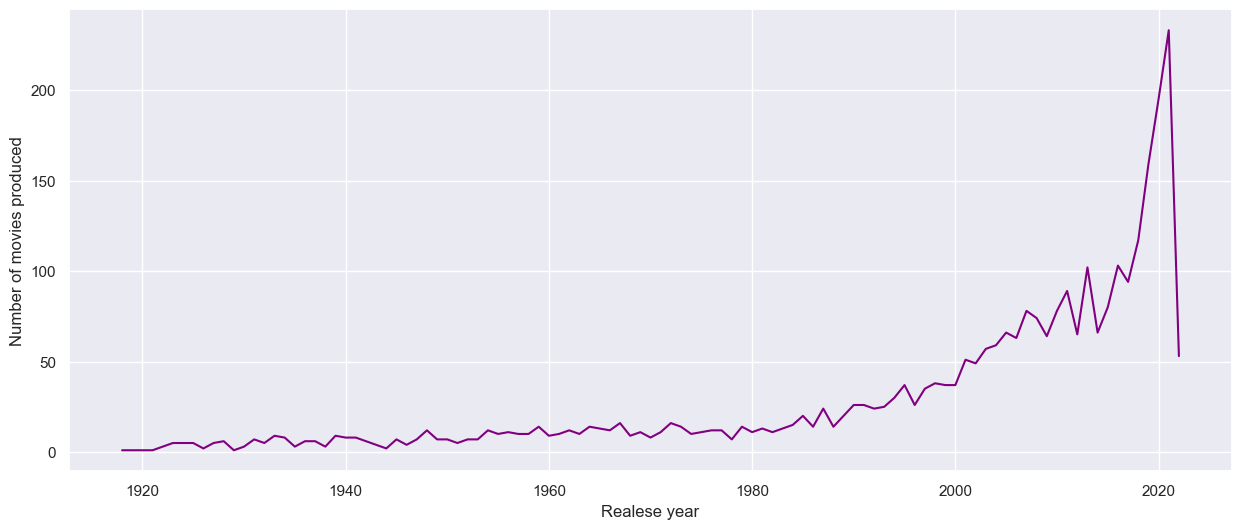

In [ ]:
#1.How has the number of movies and TV shows released changed over the years?
plt.figure(figsize=(15,6))
year_count=df_title['release_year'].value_counts()
sns.lineplot(x=year_count.index,y=year_count,color='purple')
plt.xlabel("Realese year")
plt.ylabel("Number of movies produced")
plt.show()


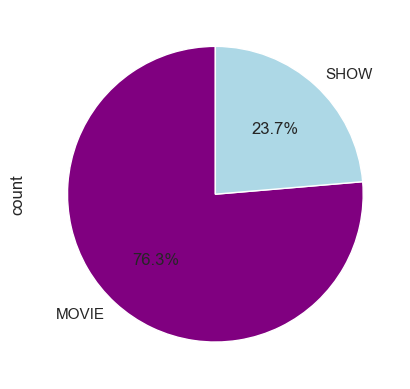

In [ ]:
# 2.What is the distribution of content types (Movies vs TV Shows)?
colors=['purple','lightblue']
type=df_title['type'].value_counts().plot(kind='pie',autopct='%1.1f%%',colors=colors,startangle=90)
plt.show()



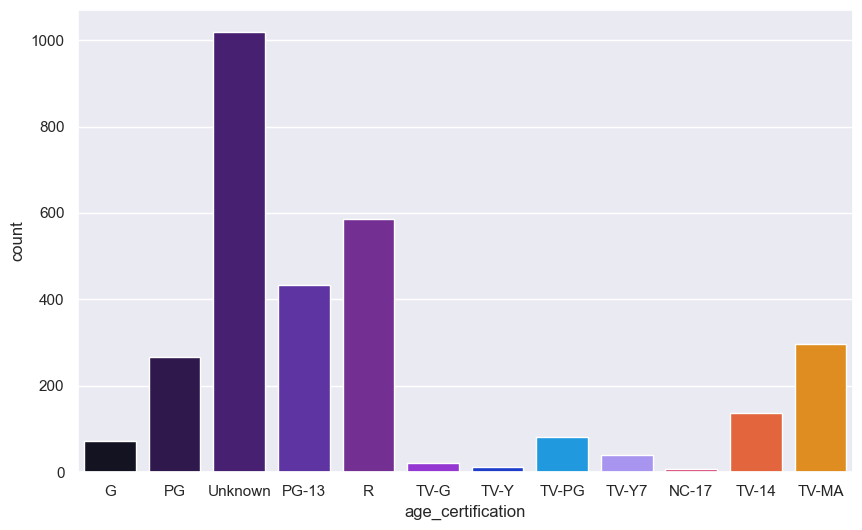

In [ ]:
# 3.What is the distribution of age certification categories?
plt.figure(figsize=(10,6))
sns.countplot(data=df_title,x="age_certification",hue='age_certification',palette=hbo_max_colors)
plt.show()

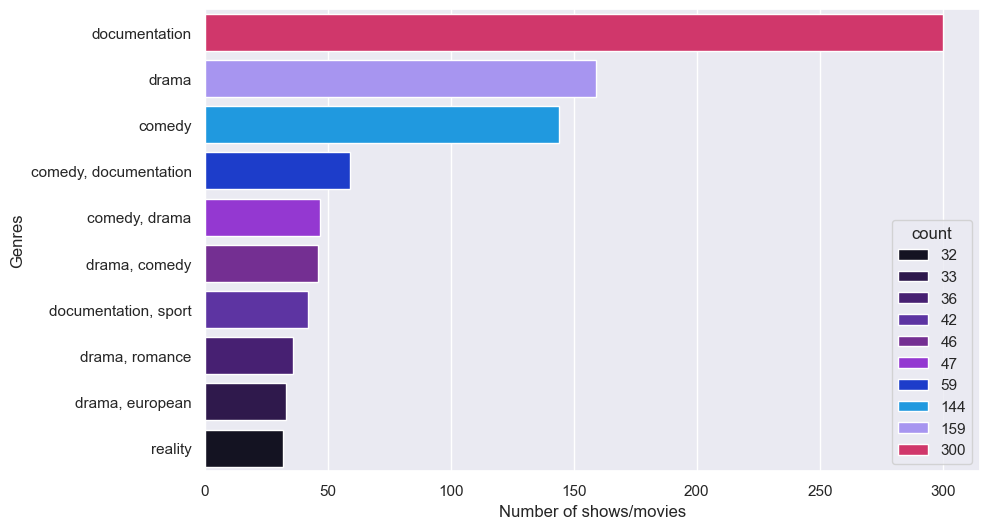

In [ ]:
#4.What is the most common genre?
plt.figure(figsize=(10,6))
genre=df_title['genres'].value_counts().head(10)
sns.barplot(x=genre,y=genre.index,hue=genre,palette=hbo_max_colors)
plt.xlabel('Number of shows/movies')
plt.ylabel('Genres')
plt.show()

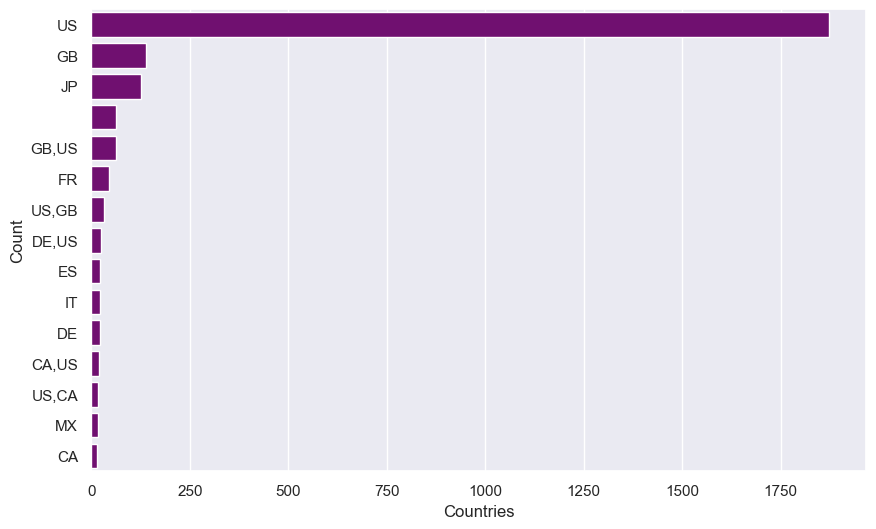

In [ ]:
# 5.Which countries produced the most movies and TV shows?
plt.figure(figsize=(10,6))
countries=df_title.explode('production_countries')['production_countries'].value_counts().head(15)
sns.barplot(y=countries.index,x=countries,color='purple')
plt.xlabel("Countries")
plt.ylabel("Count")
plt.show()

## Bivariate Analysis

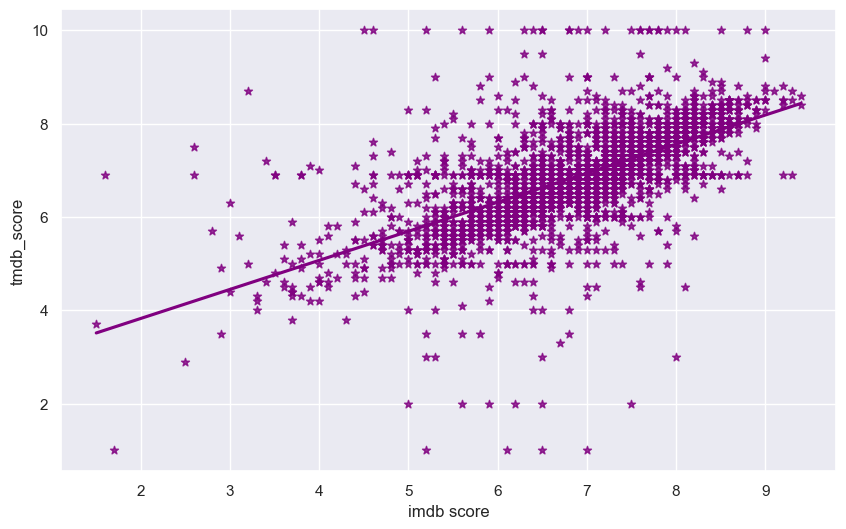

In [ ]:
#6.Is there a correlation between IMDb votes and IMDb score?
plt.figure(figsize=(10,6))
colors=['lightblue','purple']
sns.regplot(data=df_title,x="imdb_score",y='tmdb_score',ci=None,color='purple',marker='*')
plt.xlabel("imdb score")
plt.ylabel("tmdb_score")
plt.show()

<Figure size 1000x600 with 0 Axes>

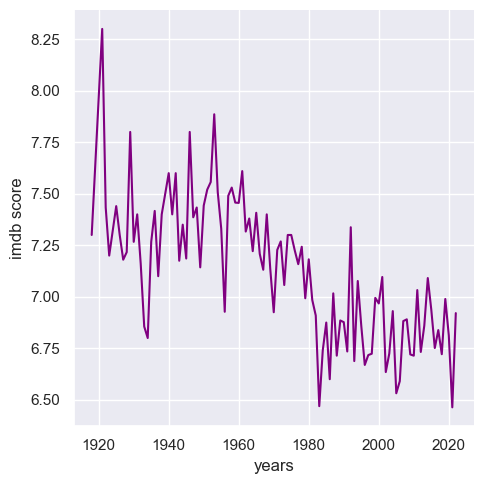

In [ ]:
#7.How has the average IMDb score changed over the years?  
plt.figure(figsize=(10,6))
imdb_trend=df_title.groupby("release_year")['imdb_score'].mean()
sns.relplot(kind='line',x=imdb_trend.index,y=imdb_trend,color='purple')
plt.xlabel("years")
plt.ylabel( "imdb score")
plt.show()

<Figure size 1500x800 with 0 Axes>

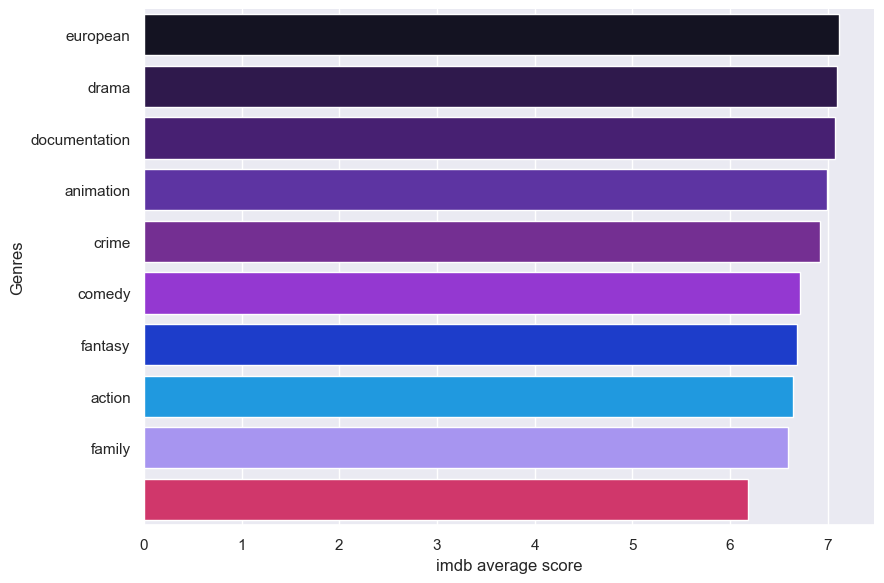

In [ ]:
# 8.Which genres have the highest average IMDb scores?
plt.figure(figsize=(15,8))
df_title['genres']=df_title['genres'].str.split(',')
genre_exp=df_title.explode('genres',ignore_index=True)
genre_exp['genres'] = genre_exp['genres'].str.strip()
imdb_avg=genre_exp.groupby('genres')['imdb_score'].mean().head(10).sort_values(ascending=False)
sns.catplot(kind='bar',x=imdb_avg.values,y=imdb_avg.index,hue=imdb_avg.index,palette=hbo_max_colors,height=6,aspect=1.5)
plt.xlabel("imdb average score")
plt.ylabel("Genres")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

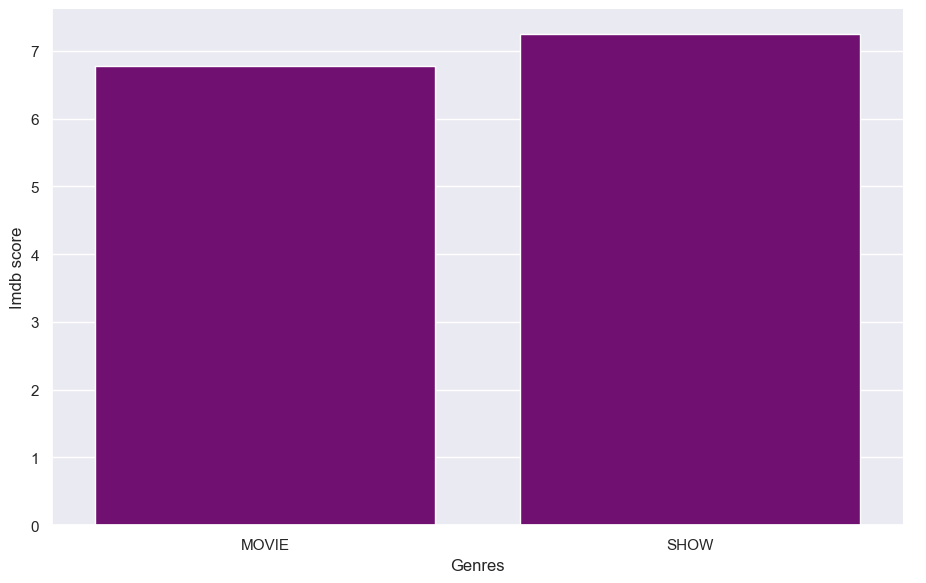

In [ ]:
# 9.Do movies or TV shows have higher IMDb scores?  
plt.figure(figsize=(10,6))
type_imdb=df_title.groupby('type')['imdb_score'].mean()
sns.catplot(kind='bar',x=type_imdb.index,y=type_imdb.values,color='purple',height=6,aspect=1.5)
plt.xlabel("Genres")
plt.ylabel('Imdb score')
plt.show()

<Figure size 1500x800 with 0 Axes>

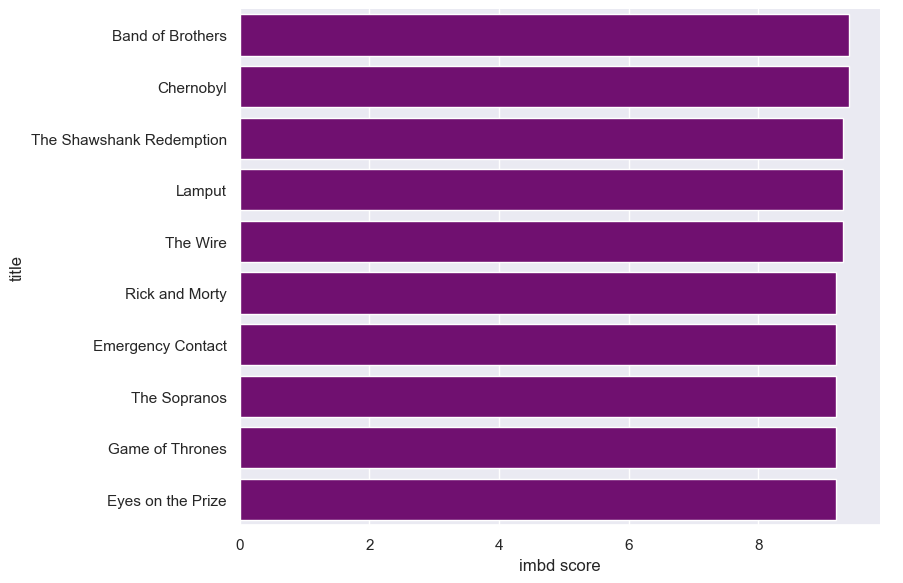

In [ ]:
# 10.Which movies or TV shows have the highest IMDb scores? 
title_imdb = df_title[['title', 'imdb_score']].sort_values(by='imdb_score', ascending=False).head(10)
hue_title=df_title['type']
plt.figure(figsize=(15,8))
sns.catplot(kind='bar',data=title_imdb,x='imdb_score',y='title',color='purple',height=6,aspect=1.5)
plt.xlabel("imbd score")
plt.ylabel("title")
plt.show()

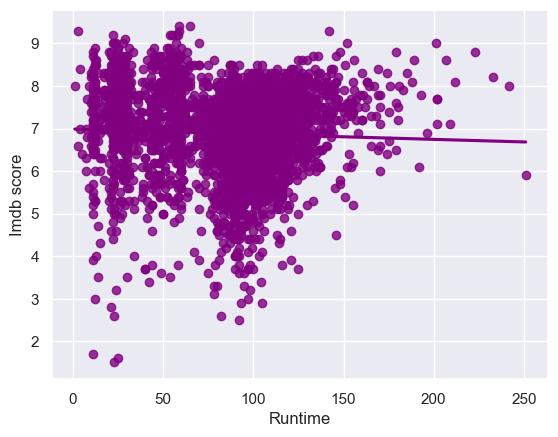

In [ ]:
# 11.Does runtime affect IMDb score?
sns.regplot(data=df_title,x='runtime',y='imdb_score',ci=None,color='purple')
plt.xlabel('Runtime')
plt.ylabel('Imdb score')
plt.show()

In [ ]:
df.head(1)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"fantasy, family",US,0.0,tt0032138,8.1,389774.0,41.442,7.6,60017,Judy Garland,Dorothy Gale,ACTOR


In [ ]:
top_actors=df.groupby('name')['title'].count().sort_values(ascending=False).head(10)
top_actors

name
Frank Welker                26
Kevin Michael Richardson    24
Tara Strong                 23
Grey DeLisle                23
Samuel L. Jackson           21
Tom Kenny                   20
Fred Tatasciore             19
Liev Schreiber              18
Dee Bradley Baker           18
Matt Damon                  18
Name: title, dtype: int64

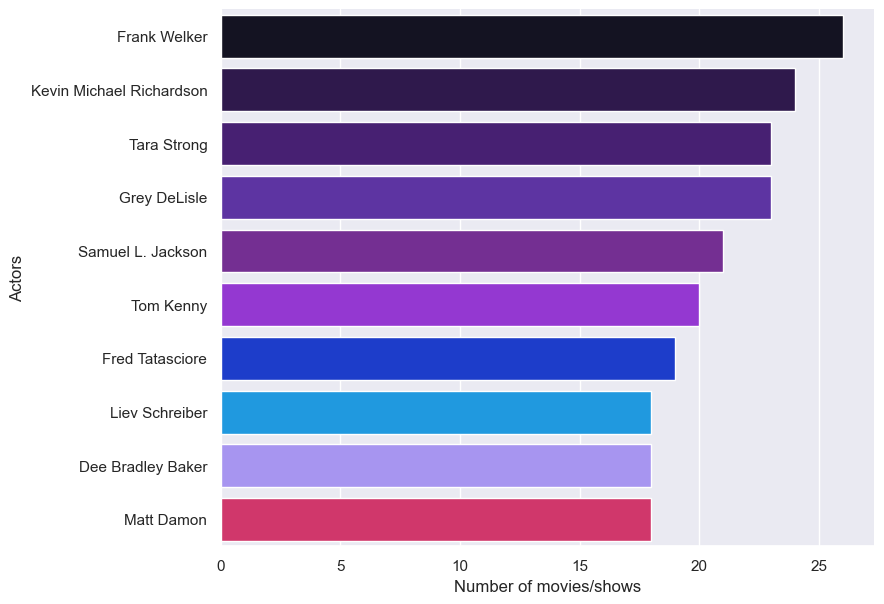

In [ ]:
# 12.Which actors have appeared in the most titles?
top_actors=df.groupby('name')['title'].count().sort_values(ascending=False).head(10)
sns.catplot(kind='bar',x=top_actors.values,y=top_actors.index,hue=top_actors.index,palette=hbo_max_colors,height=6,aspect=1.5)
plt.xlabel('Number of movies/shows')
plt.ylabel('Actors')
plt.show()

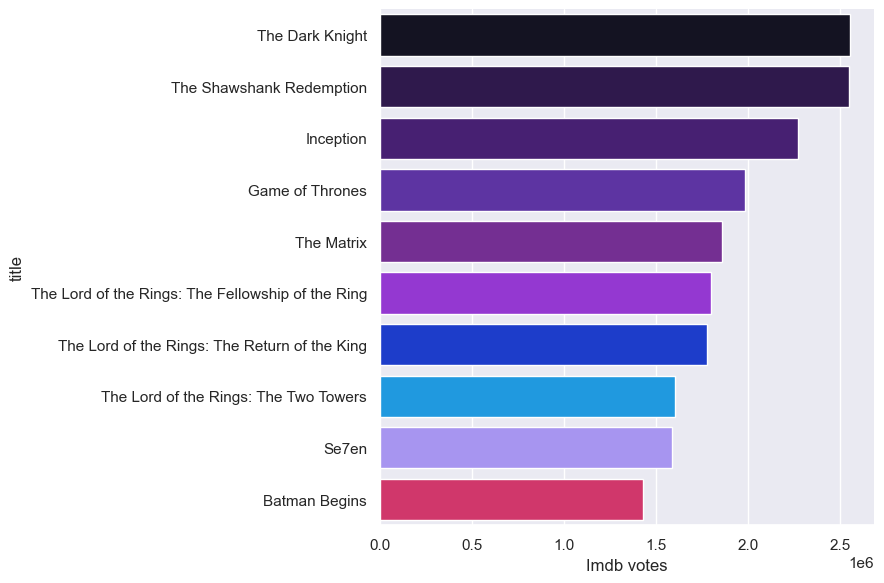

In [ ]:
# 13.Which titles have the highest IMDb votes?
title_votes=df_title[['title','imdb_votes']].sort_values(by='imdb_votes',ascending=False).head(10)
sns.catplot(kind='bar',data=title_votes,x='imdb_votes',y='title',hue='title',palette=hbo_max_colors,height=6,aspect=1.5)
plt.xlabel('Imdb votes')
plt.ylabel('title')
plt.show()

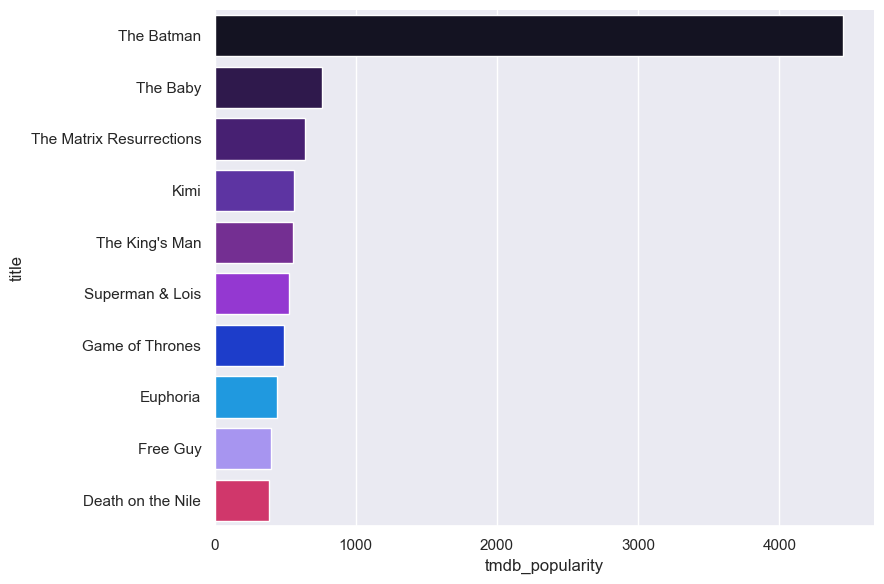

In [ ]:
# 14.Which titles have the highest TMDB popularity?
title_tmdb=df_title[['title','tmdb_popularity']].sort_values(by='tmdb_popularity',ascending=False).head(10)
sns.catplot(kind='bar',data=title_tmdb,x='tmdb_popularity',y='title',hue='title',palette=hbo_max_colors,height=6,aspect=1.5)
plt.xlabel('tmdb_popularity')
plt.ylabel('title')
plt.show()

## Multivariate analysis